# Import Libraries

In [41]:
import os
import time
import pickle
import random
import itertools

# Analisi dati e Visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    GridSearchCV,
    RandomizedSearchCV,
    ParameterGrid
)
from sklearn.pipeline import Pipeline

# Scikit-learn: Modelli di Machine Learning Classico
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import plot_tree

# Imbalanced Learning (SMOTE e Pipeline compatibile)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metriche di Valutazione
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

# Deep Learning (PyTorch) e Monitoraggio
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import datetime

# Our packages
from utils import *
from plot import *

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.compose import make_column_selector
from sklearn import set_config



# Global Variables

In [42]:
SEED = 42
FILENAME = "../../data/train.csv"

# Cerca la GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

No GPU acceleration available.


In [43]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(SEED)

# Load the dataset

In [44]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [45]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


##################################################
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction and train-test splitting

In [46]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [47]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

In [48]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

## 3. Pipeline

In [49]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """ Drop generic columns """
    def __init__(self, columns=[]):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class HighNanDropper(BaseEstimator, TransformerMixin):
    """ Rimuove colonne con alto numero di NaN"""
    
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.columns = []

    def fit(self, X, y=None):
        nan_ratio = X.isna().mean()
        self.columns = nan_ratio[nan_ratio > self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class HighlyCorrelatedDropper(BaseEstimator, TransformerMixin):
    """" Rimozione delle feature ridondanti identificate (High Correlation > threshold) """
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.columns = []

    def fit(self, X, y=None):
        numeric_df = X.select_dtypes(include=[np.number])
        corr_matrix = numeric_df.corr().abs()
        # Selezioniamo il triangolo superiore della matrice; k=1 esclude la diagonale principale
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns = [column for column in upper_tri.columns if any(upper_tri[column] > self.threshold)]
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[col for col in self.columns if col in X.columns])
    

class NumericExtractor(BaseEstimator, TransformerMixin):
    """ Estrae feature numeriche da stringhe (36/60 mesi, polishing anni di carriera...) """
    def __init__(self, columns=[]):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        valid_cols = [col for col in self.columns if col in X.columns]
        for col in valid_cols:
            X[col] = (X[col].astype(str)
                        .replace('< 1', '0') 
                        .str.extract(r"(\d+)")
                        .astype(float))
        return X
    
    
class FeatureAverager(BaseEstimator, TransformerMixin):
    """Media di n colonne e rimuove gli originali"""
    def __init__(self, columns=[], new_name='new_avg_col'):
        self.columns = columns
        self.new_name = new_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Calcoliamo la media lungo l'asse delle righe (axis=1)
        valid_cols = [col for col in self.columns if col in X.columns]
        if valid_cols:
            X[self.new_name] = X[valid_cols].mean(axis=1)
        return X.drop(columns=[col for col in self.columns if col in X.columns])

    
class DateDifferenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, reference_col, target_cols=None):
        self.reference_col = reference_col
        self.target_cols = target_cols or []
        self.date_format = '%b-%Y'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        # Check if reference exists
        if self.reference_col not in X.columns:
            return X # Skip if ref is missing (maybe dropped by NaN filter)

        ref_series = pd.to_datetime(X[self.reference_col], format=self.date_format, errors='coerce')
        
        # Ensure targets is a list and filter for existence
        targets = [self.target_cols] if isinstance(self.target_cols, str) else self.target_cols
        valid_targets = [col for col in targets if col in X.columns]
        
        cols_to_drop = []

        for col in valid_targets:
            target_series = pd.to_datetime(X[col], format=self.date_format, errors='coerce')
            new_col_name = f"months_since_{col}"

            X[new_col_name] = (
                (ref_series.dt.year - target_series.dt.year) * 12 +
                (ref_series.dt.month - target_series.dt.month)
            )
            X[new_col_name] = np.round(X[new_col_name]).astype('Int64')
            cols_to_drop.append(col)

        # Drop columns
        all_drops = cols_to_drop + [self.reference_col]
        # Final safety check before drop
        X = X.drop(columns=[c for c in all_drops if c in X.columns], errors='ignore')

        return X
    

class RoundToIntTransformer(BaseEstimator, TransformerMixin):
    """ Arrotonda le colonne selezionate all'intero piu vicino """
    def __init__(self, columns=[]):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in [c for c in self.columns if c in X.columns]:
                X[col] =  np.round(X[col]).astype('Int64')
        return X
    



In [50]:
loan_performance_data_leakage = [
    'loan_status_current_code',                         # prestito in regola, in ritardo, totalmente pagato...
    'outstanding_principal_balance',                    # "outstanding principal" e' la parte del capitale da restituire
    'outstanding_principal_investor_side',              # similmente
    'total_payment_received',                           # somma pagata al creditore
    'total_payment_investor_side',
    'total_received_principal',                         # somma pagata al creditore che copre la il capitale del prestito
    'total_received_interest',                          # ... copre gli interessi
    'total_received_late_fees',                         # ... copre le penali
    'recoveries_cash',                                  # somma recuperata dopo un prestito andato in default
    'collection_recovery_fee',                          # spese per il recupero crediti
    'last_payment_date',                                # data ultimo pagamento effettuato
    'last_payment',                                     # importo ultimo pagamento
    'next_payment_date',                                # data prossimo pagamento
    'last_credit_pull_date',                            # data ultimo check profilo creditizio, durante il periodo di prestito
    'last_fico_score_high_bound',                       # ultimo punteggio FICO rilevato: al momento della concessione del prestito si usa 'fico_score_low_bound', 'fico_score_high_bound
    'last_fico_score_low_bound',
    'total_collection_amount',
    'loan_payment_installments_count'                   # potrebbe semprare il numero di rate, ma la tipologia di valori contenuti fa pensare al valore economico della singola rata (calcolo derivante di interest rate)
]

# Il tasso di interesse di un prestito è calcolato basandosi sul Grading assegnato al prestito stesso.
# Essendo una conseguenza del nostro target "grade", è da considerarsi data leakage
# https://www.airtel.in/blog/personal-loan/how-does-loan-grading-work/ (Accessed 02/02/2026)
loan_contract_interest_rate = [
    'loan_contract_interest_rate'
]

# "Settlement" indica una situazione avvenuta durante / dopo il prestito, non al momento della concessione
settlement_data_leakage = [
    'debt_settlement_flag_indicator',
    'settlement_status_label',
    'settlement_amount_total', 
    'settlement_percentage', 
    'settlement_term_months'
]

# "Hardship loans" sono concessioni per agevolare il pagamento di un prestito quando il debitore si trova in momenti di difficoltà economica (perdita lavoro, problemi medici, disastri naturali)
# https://www.oaic.gov.au/privacy/your-privacy-rights/credit-reporting/hardship-assistance/what-is-a-financial-hardship-arrangement
# https://financialrights.org.au/factsheet/financial-hardship/
hardship_data_leakage = [
    'hardship_flag_indicator',
    'hardship_type_label',
    'hardship_reason_label',
    'hardship_status_label',
    'hardship_deferral_term_months',
    'hardship_amount_total',
    'hardship_duration_days',
    'hardship_days_past_due',
    'hardship_loan_status_label',
    'hardship_payoff_balance',
    'hardship_last_payment_amount_total'
]

other_leakage = [
    'original_projected_additional_accrued_interest',           # interesse addizionale previsto, presumibilmente in seguito a modifiche di piani ammortamento o hardship
    #'loan_issue_date',                                         # Il grade è influenzato dalla situazione creditizia del richiedente, più che dal periodo
                                                                # droppato in un secondo momento, dopo averlo usato per feature extraction
    'investor_side_funded_amount',
    'loan_portfolio_total_funded',
]

other_non_significant = [
    'platform_policy_code_id',                                      # id interno al prestatore
    'loan_title',                                                   # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
    'borrower_address_zip',                                         # non significant column, esiste una colonna per identificazione stati
]

####################################################################################################
joint_and_secondary_cols = [
    'joint_income_annual',
    'joint_dti_ratio',
    'joint_income_verification_status',
    'joint_revolving_balance',
    'secondary_applicant_fico_low',
    'secondary_applicant_fico_high',
    'secondary_applicant_earliest_credit_line',
    'secondary_applicant_inquiries_6m',
    'secondary_applicant_mortgage_accounts',
    'secondary_applicant_open_accounts',
    'secondary_applicant_revolving_utilization',
    'secondary_applicant_open_active_installment_loans',
    'secondary_applicant_revolving_accounts',
    'secondary_applicant_chargeoffs_12m',
    'secondary_applicant_collections_12m_ex_med',
    'secondary_applicant_months_since_last_major_derog'
]

####################################################################################################
number_from_string_cols = [
    'loan_contract_term_months',            # 36 mesi / 60 mesi
    'borrower_profile_employment_length',   # < 1 years, 10+ years
]

average_cols = [
    'fico_score_low_bound',
    'fico_score_high_bound'
]

date_diff_reference = 'loan_issue_date'
date_diff_target = [ 'credit_history_earliest_line' ]

####################################################################################################

# Lista delle feature che richiedono valori interi: conteggi di linee di credito e conti, mesi, fico score
round_to_nearest_int = [
    # Months
    'loan_contract_term_months',
    'months_since_last_delinquency',
    'months_since_last_public_record',
    'months_since_last_major_derog',
    'months_since_recent_installment_loan',
    'months_since_oldest_installment_acct',
    'months_since_oldest_revolving_acct',
    'months_since_recent_revolving_acct',
    'months_since_recent_trade_line',
    'months_since_recent_bankcard',
    'months_since_recent_bankcard_delinquency',
    'months_since_recent_inquiry',
    'months_since_recent_revolving_delinquency',
    'months_since_credit_history_earliest_line',

    # account, eventi, inquiry, delinquency
    'credit_delinquencies_2yrs',
    'credit_inquiries_6m',
    'credit_open_accounts',
    'credit_public_records',
    'collections_12m_ex_med',
    'accounts_now_delinquent',
    'open_accounts_6m',
    'open_active_installment_loans',
    'open_installment_loans_12m',
    'open_installment_loans_24m',
    'open_revolving_accounts_12m',
    'open_revolving_accounts_24m',
    'finance_inquiries',
    'credit_union_trades_total',
    'credit_inquiries_12m',
    'accounts_open_past_24m',
    'chargeoffs_within_12m',
    'mortgage_accounts',
    'accounts_ever_120dpd',
    'active_bankcard_tradelines',
    'active_revolving_tradelines',
    'bankcard_satisfactory_accounts',
    'bankcard_tradelines',
    'installment_tradelines',
    'open_revolving_tradelines',
    'revolving_accounts',
    'tradelines_120dpd_2m',
    'tradelines_30dpd',
    'tradelines_90dpd_24m',
    'tradelines_open_past_12m',
    'public_record_bankruptcies',
    'tax_liens_total',

    'borrower_profile_employment_length',
    'fico_average'

]

####################################################################################################

categorical_to_unknown_cols = [
  'borrower_address_state',
  'loan_purpose_category',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

fill_big_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency', 
    'months_since_recent_inquiry', 
    'months_since_recent_bankcard',
    'months_since_recent_trade_line'
]

fill_zero_cols = [
    'open_accounts_6m', 'open_installment_loans_12m', 'open_installment_loans_24m',
    'open_revolving_accounts_12m', 'open_revolving_accounts_24m',
    'finance_inquiries', 'credit_inquiries_12m', 'credit_union_trades_total',
    'open_active_installment_loans', 'tradelines_open_past_12m', 'accounts_open_past_24m',
    'open_revolving_tradelines', 'active_bankcard_tradelines', 'installment_tradelines',
    'revolving_accounts', 'bankcard_satisfactory_accounts', 'active_revolving_tradelines', 
    'bankcard_tradelines', 'credit_open_accounts', 'credit_total_accounts',
    'tradelines_120dpd_2m', 'tradelines_30dpd', 'tradelines_90dpd_24m',
    'accounts_ever_120dpd', 'chargeoffs_within_12m', 'collections_12m_ex_med',
    'accounts_now_delinquent', 'public_record_bankruptcies', 'credit_public_records',
    'credit_delinquencies_2yrs', 'tax_liens_total', 'borrower_profile_employment_length'
]

fill_to_mode_cat = [
    'disbursement_method_type',
    'application_type_label',
    'listing_initial_status',
    'loan_payment_plan_flag'         # n/y
]

fill_to_mode_num = [
    'loan_contract_term_months'    # 36/60 mesi
]

In [27]:
remainder_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('impute_unknown', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_to_unknown_cols),
        ('impute_0', SimpleImputer(strategy='constant', fill_value=0), fill_zero_cols),
        ('impute_10k', SimpleImputer(strategy='constant', fill_value=999), fill_big_cols),
        ('impute_mode_cat',SimpleImputer(strategy='most_frequent'), fill_to_mode_cat),
        ('impute_mode_num', SimpleImputer(strategy='most_frequent'), fill_to_mode_num),
    ],
    remainder=remainder_pipeline,
    verbose_feature_names_out=False
)


encoding = ColumnTransformer(
    transformers=[
        # Applica categorical_pipe a TUTTE le colonne di tipo object o category
        ('cat_step', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(dtype_include=['object'])),
    ], 
    # Tutto ciò che è numerico e non è stato toccato sopra, viene scalato qui
    remainder="passthrough", 
    verbose_feature_names_out=False
)

In [ ]:

full_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(columns = loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    ('drop_non_significant', ColumnDropper(columns = other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    ('drop_joint_and_secondary', ColumnDropper(columns = joint_and_secondary_cols)),
    ('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns = number_from_string_cols)),
    ('fico_average', FeatureAverager(columns = average_cols)),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns = round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),
    
    ("clf", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
])

param_grid_rf = {
    'clf__n_estimators': [250, 300],
    'clf__criterion': ['gini', 'log_loss'],
    'clf__max_depth': [10, 20]
}

scoring = {
    'acc': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'f1_weighted': 'f1_weighted'
}

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring='balanced_accuracy',
    #refit='balanced_acc', 
    error_score='raise',
    n_jobs=-1,
    verbose=3
)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


[CV 1/3] END ..................................., score=0.324 total time=  30.7s
[CV 3/3] END ..................................., score=0.323 total time=  30.8s
[CV 2/3] END ..................................., score=0.322 total time=  31.4s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes a

In [29]:
import pickle

# 1. Recuperiamo il miglior stimatore
full_best_pipeline = grid.best_estimator_

print("Migliori parametri:", grid.best_params_)
print(f"Miglior CV Score: {grid.best_score_:.4f}")

# 2. Dividiamo la Pipeline
# [:-1] prende tutto tranne l'ultimo step ('clf')
preprocessing_part = full_best_pipeline[:-1] 
# Accediamo al classificatore tramite il suo nome 'clf'
classifier_part = full_best_pipeline.named_steps['clf']

# 3. Salvataggio (Uso .pkl o .joblib per convenzione)
try:
    with open("rf_preprocessor.save", "wb") as f:
        pickle.dump(preprocessing_part, f)

    with open("rf.save", "wb") as f:
        pickle.dump(classifier_part, f)
        
    print("\nFile salvati correttamente:")
    print("- 'rf_preprocessor.save' (Contiene tutti i drop e le trasformazioni)")
    print("- 'rf.save' (Contiene solo il RandomForestClassifier allenato)")
except Exception as e:
    print(f"Errore durante il salvataggio: {e}")

Migliori parametri: {}
Miglior CV Score: 0.3226

File salvati correttamente:
- 'rf_preprocessor.save' (Contiene tutti i drop e le trasformazioni)
- 'rf.save' (Contiene solo il RandomForestClassifier allenato)


REPORT VALUTAZIONE: RF
Workflow rilevato: Preprocessor (Custom Pipeline)
Parametri RF: n_estimators=100, max_depth=None, class_weight=balanced
----------------------------------------

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.70      0.66      0.68      6634
           1       0.44      0.57      0.50      9435
           2       0.37      0.53      0.43      9270
           3       0.26      0.12      0.17      5314
           4       0.30      0.12      0.17      3021
           5       0.33      0.13      0.19      1881
           6       0.40      0.16      0.23      1521

    accuracy                           0.44     37076
   macro avg       0.40      0.33      0.34     37076
weighted avg       0.42      0.44      0.41     37076

Accuracy Score:          0.4377
Balanced Accuracy Score: 0.3282


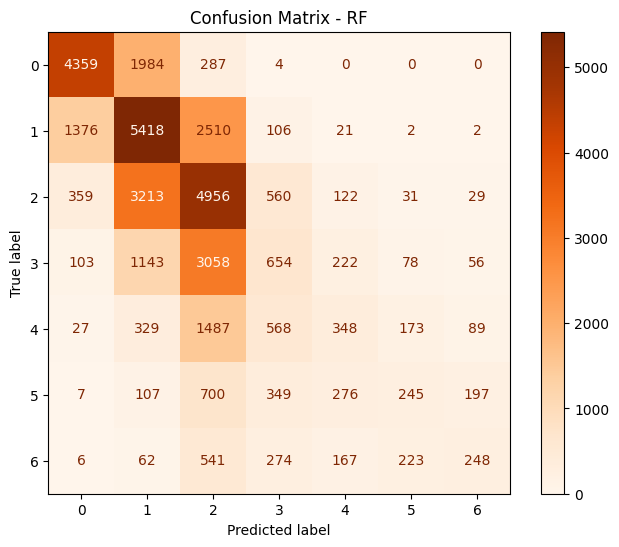

In [30]:
evaluate_model(X_val, y_val, "rf")

# Feed Forward Neural Network

In [51]:
# Define the Data Layer

class MyDataset(Dataset):
    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

        self.num_samples = X.shape[0]         # Definisco numero di samples
        self.num_features = X.shape[1]        # Definisco numero di feature
        self.num_classes = len(np.unique(y))  # Definisco numero di classi


    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx, :], self.y[idx]

In [52]:
def test_model(model, data_loader, device):
    model.eval()
    y_pred = []
    y_test = []

    for data, targets in data_loader:
        data, targets = data.to(device), targets.to(device)
        y_pred += model(data)
        y_test += targets

    y_test = torch.stack(y_test).squeeze()
    y_pred = torch.stack(y_pred).squeeze()
    y_pred_c = y_pred.argmax(dim=1, keepdim=True).squeeze()

    return y_test, y_pred_c, y_pred

In [53]:
def train_model(model, criterion, optimizer, n_epochs, scheduler, train_loader, val_loader, device, writer, log_name="best_model"):
    n_iter = 0
    best_valid_loss = float('inf')
    for ep in range(n_epochs):
        model.train()

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()

            # Forward pass
            y_pred = model(data)

            # Compute Loss
            loss = criterion(y_pred, targets)
            writer.add_scalar("Loss/train", loss, n_iter)

            # Backward pass
            loss.backward()
            optimizer.step()

            n_iter += 1

        # --- VALIDATION PHASE ---
        # test_model restituisce (labels_reali, predizioni_classi, probabilità_output)
        labels_val, preds_val, y_output_val = test_model(model, val_loader, device)

        # 1. Calcolo Loss di Validation
        loss_val = criterion(y_output_val, labels_val)
        writer.add_scalar("Loss/val", loss_val, ep)

        # 2. CALCOLO ACCURACY DI VALIDATION
        # Calcoliamo quante predizioni sono uguali alle label reali
        acc_val = (preds_val == labels_val).float().sum() / labels_val.shape[0]
        #acc = (preds_val == labels_val).float().mean().item()
        # Log dell'accuracy su TensorBoard
        writer.add_scalar("Accuracy/val", acc_val, ep)

        print(f"Epoch {ep+1}/{n_epochs} - Loss Val: {loss_val:.4f} - Acc Val: {acc_val:.2f}%")

        # Save best model basandosi sulla loss (o potresti usare acc_val)
        if loss_val.item() < best_valid_loss:
            best_valid_loss = loss_val.item()
            if not os.path.exists('models'):
                os.makedirs('models')
            torch.save(model.state_dict(), 'models/'+log_name)

        writer.add_scalar("Learning Rate", scheduler.get_last_lr()[0], ep)

        scheduler.step()

    return model

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (111225, 144), Validation: (37076, 144)


In [54]:
preprocessing_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(columns=loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    ('drop_non_significant', ColumnDropper(columns=other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    ('drop_joint_and_secondary', ColumnDropper(columns=joint_and_secondary_cols)),
    ('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns=number_from_string_cols)),
    ('fico_average', FeatureAverager(columns=average_cols)),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns=round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),

    ('scaler', MinMaxScaler())
])

In [55]:
X_train = preprocessing_pipeline.fit_transform(X_train).to_numpy()
X_val = preprocessing_pipeline.transform(X_val).to_numpy()

# Create the torch dataset
train_subset = MyDataset(X_train,y_train)
val_subset = MyDataset(X_val,y_val)

/tmp/ipykernel_36556/409326700.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self.X = torch.FloatTensor(X)


In [56]:
# Let's define a new architecture inlcuding also Dropout
class FeedForward_OurNN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_rate, depth=1):
        super(FeedForward_OurNN, self).__init__()

        model = [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        block = [
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        for i in range(depth):
            model += block

        self.model = nn.Sequential(*model)

        self.output = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        h = self.model(x)
        out = self.output(h)
        return out

In [ ]:

# --- 1. Definizione della Griglia degli Iperparametri ---
param_grid = {
    'batch_size': [256, 512, 1024],
    'hidden_size': [100, 150, 200],
    'depth': [1, 2],
    'dropout_rate': [0.2, 0.3],
    'learning_rate': [0.001, 0.01]
}

# Parametri fissi
num_epochs = 50
gamma = 0.5
step_size = 10

# Genera tutte le combinazioni possibili
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_val_acc_overall = 0.0
best_config = None
best_run_name = "" # Inizializza fuori dal ciclo for

# --- 2. Ciclo di Iterazione ---
for i, config in enumerate(combinations):
    # Estrazione parametri correnti
    bs = config['batch_size']
    hs = config['hidden_size']
    d = config['depth']
    dr = config['dropout_rate']
    learning_rate = config['learning_rate']

    print(f"\n[Run {i+1}/{len(combinations)}] Testing: {config}")

    # Fix the seed for reproducibility ad ogni inizio ciclo
    fix_random(SEED)

    # Start tensorboard con nome esperimento dinamico
    exp_name = f"runs/FFNN_bs{bs}_d{d}_h{hs}_dr{dr}_lr{learning_rate}"
    writer = SummaryWriter(log_dir=exp_name)

    # Create relative dataloaders
    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=bs)

    # Define the architecture, loss and optimizer
    # Assicurati che l'ordine degli argomenti in FeedForward_OurNN sia corretto
    model = FeedForward_OurNN(train_subset.num_features, train_subset.num_classes, hs, dr, d)
    model.to(device)

    # Add model graph to TensorBoard (solo alla prima iterazione per non appesantire)
    if i == 0:
        data_sample, _ = next(iter(train_loader))
        writer.add_graph(model, data_sample.to(device))

    criterion = torch.nn.CrossEntropyLoss()
    #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    # Nome univoco per il miglior modello di QUESTA specifica run
    current_run_model_name = f"best_model_run_{i}"

    # Train the model
    # Nota: la tua funzione train_model salva già internamente il miglior modello della run in 'models/'
    model = train_model(model, criterion, optimizer, num_epochs, scheduler,
                        train_loader, val_loader, device, writer, log_name=current_run_model_name)

    # --- 3. Validazione Finale e Confronto ---
    model.load_state_dict(torch.load(f"models/{current_run_model_name}", weights_only=True))
    model.to(device)

    # Recupero predizioni
    labels_val, preds_val, _ = test_model(model, val_loader, device)

    # CONVERSIONE IN NUMPY per sklearn
    y_true = labels_val.cpu().numpy()
    y_pred = preds_val.cpu().numpy()

    # CALCOLO METRICHE
    acc = (preds_val == labels_val).float().mean().item()
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro') # Media pesata tra le classi

    print(f"--- Risultati Run {i+1} ---")
    print(f"Accuracy Standard: {acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score (Macro):  {f1_macro:.4f}")

    # Stampa il report completo (Precision, Recall per ogni classe)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # LOG SU TENSORBOARD (Hparams)
    # Aggiungiamo tutte le metriche per poterle confrontare nella tabella Hparams di TensorBoard
    writer.add_hparams(
        config,
        {
            "hparam/accuracy": acc,
            "hparam/balanced_accuracy": balanced_acc,
            "hparam/f1_macro": f1_macro
        }
    )


    # SALVATAGGIO BEST MODEL (Consiglio: usa la Balanced Accuracy o F1 se i dati sono sbilanciati)
    if balanced_acc > best_val_acc_overall:
        best_val_acc_overall = balanced_acc # Ora stiamo ottimizzando per Balanced Accuracy
        best_config = config
        best_run_name = exp_name
        torch.save(model.state_dict(), "models/BEST_OVERALL_MODEL.pth")
        print(f"!!! Nuovo miglior modello trovato nella run: {best_run_name} !!!")

    # Close tensorboard writer
    writer.flush()
    writer.close()

print("\n" + "="*40)
print(f"GRID SEARCH TERMINATA")
print(f"Miglior accuratezza: {best_val_acc_overall:.4f}")
print(f"Miglior configurazione: {best_config}")


[Run 1/72] Testing: {'batch_size': 256, 'hidden_size': 100, 'depth': 1, 'dropout_rate': 0.2, 'learning_rate': 0.001}
Epoch 1/50 - Loss Val: 1.3156 - Acc Val: 0.44%
Epoch 2/50 - Loss Val: 1.2994 - Acc Val: 0.45%
Epoch 3/50 - Loss Val: 1.2978 - Acc Val: 0.45%
Epoch 4/50 - Loss Val: 1.2881 - Acc Val: 0.45%
Epoch 5/50 - Loss Val: 1.2820 - Acc Val: 0.46%
Epoch 6/50 - Loss Val: 1.2757 - Acc Val: 0.46%
Epoch 7/50 - Loss Val: 1.2719 - Acc Val: 0.46%
Epoch 8/50 - Loss Val: 1.2698 - Acc Val: 0.46%
Epoch 9/50 - Loss Val: 1.2679 - Acc Val: 0.46%
Epoch 10/50 - Loss Val: 1.2724 - Acc Val: 0.46%
Epoch 11/50 - Loss Val: 1.2583 - Acc Val: 0.47%
Epoch 12/50 - Loss Val: 1.2573 - Acc Val: 0.47%
Epoch 13/50 - Loss Val: 1.2575 - Acc Val: 0.47%
Epoch 14/50 - Loss Val: 1.2565 - Acc Val: 0.47%
Epoch 15/50 - Loss Val: 1.2563 - Acc Val: 0.47%
Epoch 16/50 - Loss Val: 1.2574 - Acc Val: 0.47%
Epoch 17/50 - Loss Val: 1.2541 - Acc Val: 0.47%
Epoch 18/50 - Loss Val: 1.2534 - Acc Val: 0.47%
Epoch 19/50 - Loss Val: 1.2

In [ ]:
import json

# 1. Creiamo un report completo
best_model_summary = {
    "model_name": "FeedForward_OurNN",
    "best_config": best_config,
    "metrics": {
        "best_balanced_accuracy": best_val_acc_overall,
    },
    "tensorboard_log_dir": best_run_name, # Qui avrai il percorso esatto della run
    "architecture_preview": str(model)     # Salva la lista dei layer e parametri
}

# 2. Salvataggio del file JSON
with open("models/BEST_MODEL_INFO.json", "w") as f:
    json.dump(best_model_summary, f, indent=4)

print("\n" + "="*40)
print("✅ SALVATAGGIO COMPLETATO")
print(f"Pesi salvati in: models/BEST_OVERALL_MODEL.pth")
print(f"Info e Run salvate in: models/BEST_MODEL_INFO.json")
print(f"Per vedere i grafici, cerca su TensorBoard: {best_run_name}")
print("="*40)